# M2 Round 2A — Python-native EDA

Issue: [#26](../../../issues/26) — Round 2, Approach A of M2's EDA parallel track.

**Which Round 1 output this builds on, and why:** at the time this notebook was built, only
Round 1 Path A (Giti's sequential pull, PR #35) exists as working, reviewed output. Round 1 Path B
(Lerneir's concurrent client classes, issue #24) has no branch or PR yet, so there is no second
candidate to compare against — this notebook uses Path A's `data/processed/` output by default,
not by a judged comparison. If Path B lands before the Round 2 team sync, this choice should be
revisited.

**Scope** (per issue #26 definition of done): distributions, a missingness map, a correlation
matrix, ADF stationarity pre-checks, and at least 3 candidate figures with enough interpretation
to be useful to the rest of the team.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().resolve().parents[1]
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED


PosixPath('/home/nholguin/projects/DAMO-699-eda-worktree/data/processed')

## 1. Load the three processed sources

- `bank_of_canada_data.csv` — BoC policy/yield-curve series, daily, business days
- `fred_rates.csv` — US 10y treasury + fed funds rate, daily, business days
- `statcan_cpi.csv` — Canadian CPI, **monthly**, with both `reference_month` (the period the
  number describes) and `release_date` (when it was actually published — StatCan publishes CPI
  with roughly a 3-week lag)


In [2]:
boc = pd.read_csv(PROCESSED / "bank_of_canada_data.csv", parse_dates=["date"])
fred = pd.read_csv(PROCESSED / "fred_rates.csv", parse_dates=["date"])
cpi = pd.read_csv(PROCESSED / "statcan_cpi.csv", parse_dates=["reference_month", "release_date"])

for name, df in [("boc", boc), ("fred", fred), ("cpi", cpi)]:
    print(f"{name}: {df.shape}, {df.iloc[:, 0].min().date()} -> {df.iloc[:, 0].max().date()}")


boc: (4552, 12), 2009-01-02 -> 2026-06-30
fred: (4563, 3), 2009-01-02 -> 2026-06-30
cpi: (210, 3), 2009-01-01 -> 2026-06-01


## 2. Aligning three different frequencies onto one daily frame

BoC and FRED are both daily (business-day) series and merge on `date` directly. CPI is monthly
and, naively left-joined onto a daily index by `reference_month`, would show as "missing" on
every day that isn't the 1st of the month — that's not a data quality problem, it's a frequency
mismatch, and the missingness map in the next section would be misleading without correcting for
it here.

Instead, CPI is forward-filled onto the daily index keyed on **`release_date`**, not
`reference_month`: a CPI print only becomes actual public information on the day StatCan
publishes it (about 3 weeks after the reference month ends), so aligning on `reference_month`
would leak information the market didn't have yet on that date. This mirrors the release-date
mapping work already done in `config/cpi_release_dates.csv` (PR #35) and matters for any
downstream modeling that treats these as a real-time information set.


In [3]:
daily = boc.merge(fred, on="date", how="outer").sort_values("date")

cpi_daily = cpi[["release_date", "cpi_all_items"]].rename(columns={"release_date": "date"})
cpi_daily = cpi_daily.sort_values("date")

daily = daily.merge(cpi_daily, on="date", how="left").sort_values("date").reset_index(drop=True)
daily["cpi_all_items"] = daily["cpi_all_items"].ffill()
daily["cpi_yoy"] = daily["cpi_all_items"].pct_change(252) * 100

daily = daily.set_index("date")
daily.tail()


,overnight_rate,yield_2y,yield_3y,yield_5y,yield_7y,yield_10y,yield_long,usdcad_legacy,usdcad_current,usdcad,yield_spread_10y_2y,us_treasury_10y,fed_funds_rate,cpi_all_items,cpi_yoy
date,,,,,,,,,,,,,,,
2026-06-24,2.25,2.73,2.83,2.99,3.13,3.36,3.76,NaN,1.4234,1.4234,0.63,4.41,3.63,169.6,3.225806
2026-06-25,2.25,2.75,2.85,3.02,3.16,3.39,3.79,NaN,1.4204,1.4204,0.64,4.40,3.63,169.6,3.225806
2026-06-26,2.25,2.75,2.85,3.02,3.15,3.39,3.80,NaN,1.4186,1.4186,0.64,4.38,3.63,169.6,3.225806
2026-06-29,2.25,2.73,2.83,3.00,3.13,3.37,3.77,NaN,1.4206,1.4206,0.64,4.38,3.63,169.6,3.225806
2026-06-30,2.25,2.74,2.84,3.01,3.14,3.38,3.77,NaN,1.4210,1.4210,0.64,4.44,3.63,169.6,3.225806


## 3. Missingness map

Three distinct causes are expected, and the point of this map is to tell them apart rather than
flag everything as one undifferentiated "missing data" problem:

1. **`usdcad_legacy` / `usdcad_current`** — BoC switched USD/CAD series on 2017-05-01; each column
   is structurally null on the other side of that date by design (see PR #35). `usdcad` is the
   stitched column and should have far fewer gaps.
2. **`cpi_all_items` / `cpi_yoy`** — null only before the first CPI release date lands (start of
   sample) and for the `pct_change(252)` warm-up window; not a collection defect.
3. **Everything else (`yield_2y` … `us_treasury_10y`)** — small, scattered gaps (~180 rows out of
   ~4,550) most likely bank holidays that don't line up 1:1 between BoC/FRED calendars, worth a
   spot check but not a Round 1 blocker.


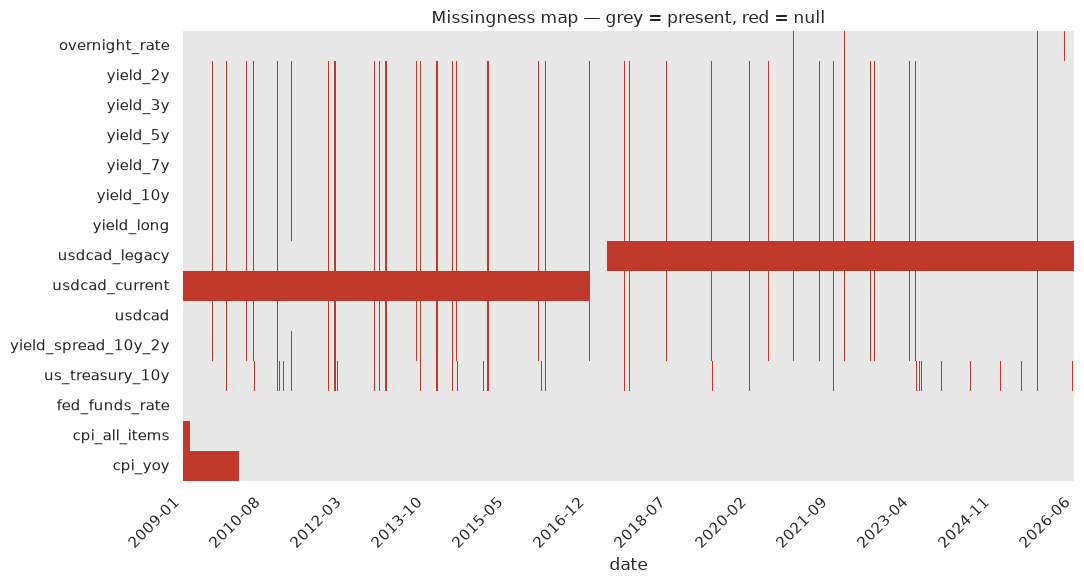

,n_missing,pct
overnight_rate,13,0.28
yield_2y,195,4.27
yield_3y,195,4.27
yield_5y,195,4.27
yield_7y,195,4.27
yield_10y,195,4.27
yield_long,195,4.27
usdcad_legacy,2478,54.31
usdcad_current,2194,48.08
usdcad,191,4.19


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(daily.isna().T, cbar=False, cmap=["#e8e8e8", "#c0392b"], ax=ax)
ax.set_title("Missingness map — grey = present, red = null")
ax.set_xlabel("date")
tick_idx = np.linspace(0, len(daily) - 1, 12).astype(int)
ax.set_xticks(tick_idx)
ax.set_xticklabels(daily.index[tick_idx].strftime("%Y-%m"), rotation=45, ha="right")
fig.tight_layout()
plt.show()

daily.isna().sum().to_frame("n_missing").assign(pct=lambda d: (d["n_missing"] / len(daily) * 100).round(2))


## 4. Distributions

Levels for the policy-rate-adjacent series (`overnight_rate`, `fed_funds_rate`) are expected to be
strongly right-skewed / multi-modal — most of the sample sits in a near-zero-rate regime
(2009–2021), with a sharp regime shift after 2022. That shape is a preview of the stationarity
result in section 6, not a data issue.


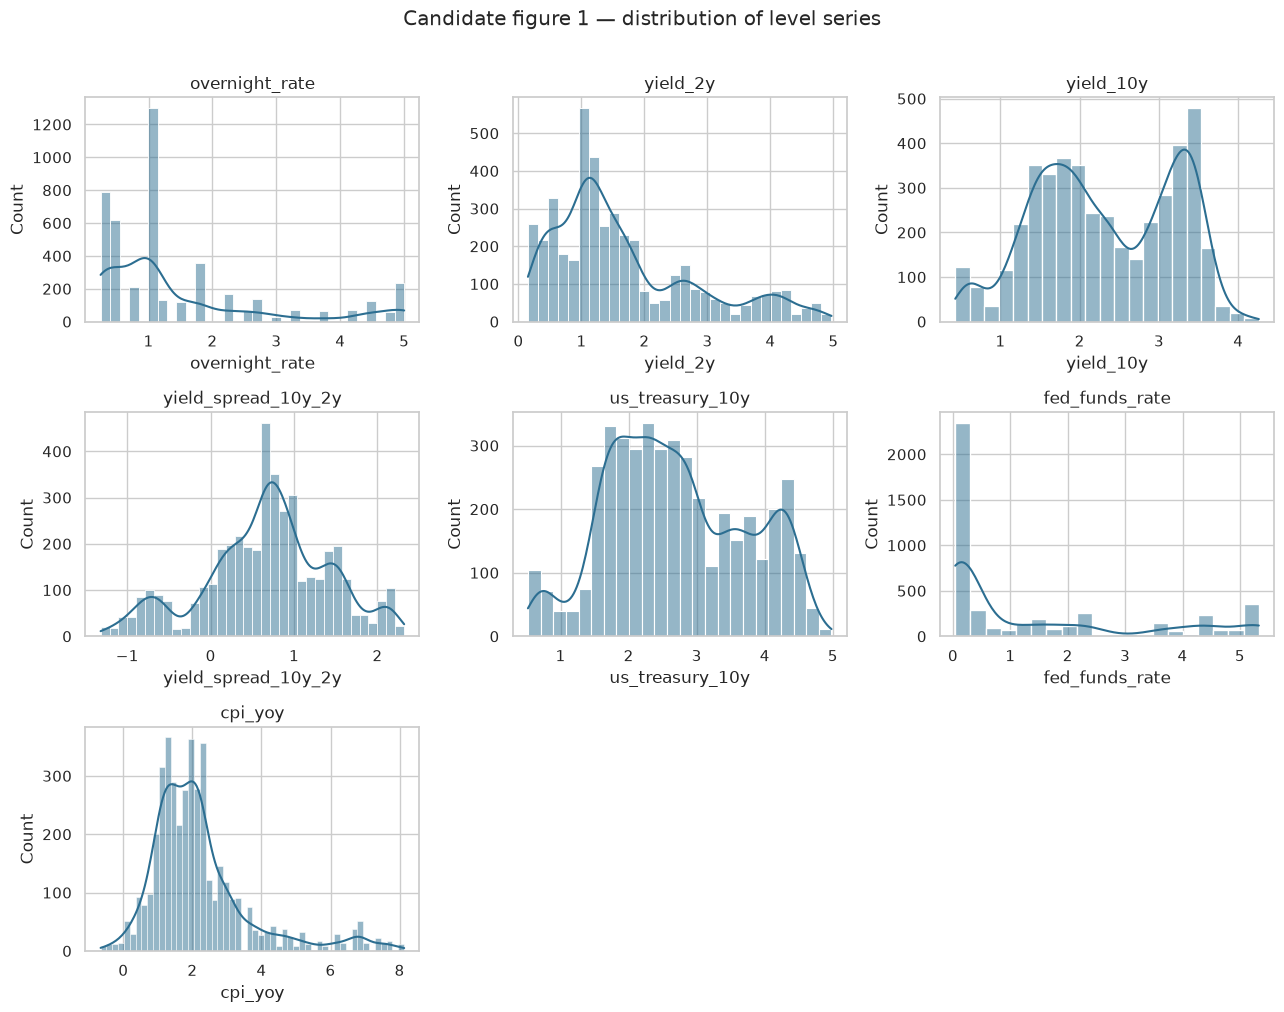

In [5]:
level_cols = [
    "overnight_rate", "yield_2y", "yield_10y", "yield_spread_10y_2y",
    "us_treasury_10y", "fed_funds_rate", "cpi_yoy",
]
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), level_cols):
    sns.histplot(daily[col].dropna(), kde=True, ax=ax, color="#2c6e91")
    ax.set_title(col)
for ax in axes.ravel()[len(level_cols):]:
    ax.axis("off")
fig.suptitle("Candidate figure 1 — distribution of level series", y=1.01)
fig.tight_layout()
plt.show()


**Interpretation:** `overnight_rate` and `fed_funds_rate` are bimodal — a long near-zero mode
(2009–2021, ZIRP-era policy) and a second mode above 4% (post-2022 hiking cycle), not a smooth
unimodal distribution. `yield_spread_10y_2y` is centered near zero but has a visible left tail —
those are the inversion episodes worth flagging for the report, not outliers to clean out.


## 5. Correlation — levels vs. first differences

Pearson correlation on **levels** of trending, non-stationary series is a well-known trap: two
unrelated random walks will show high correlation purely because both drift over time. The levels
heatmap is shown first because it's the naive thing to reach for, then the differenced version
right after — that's the one that should actually inform modeling choices.


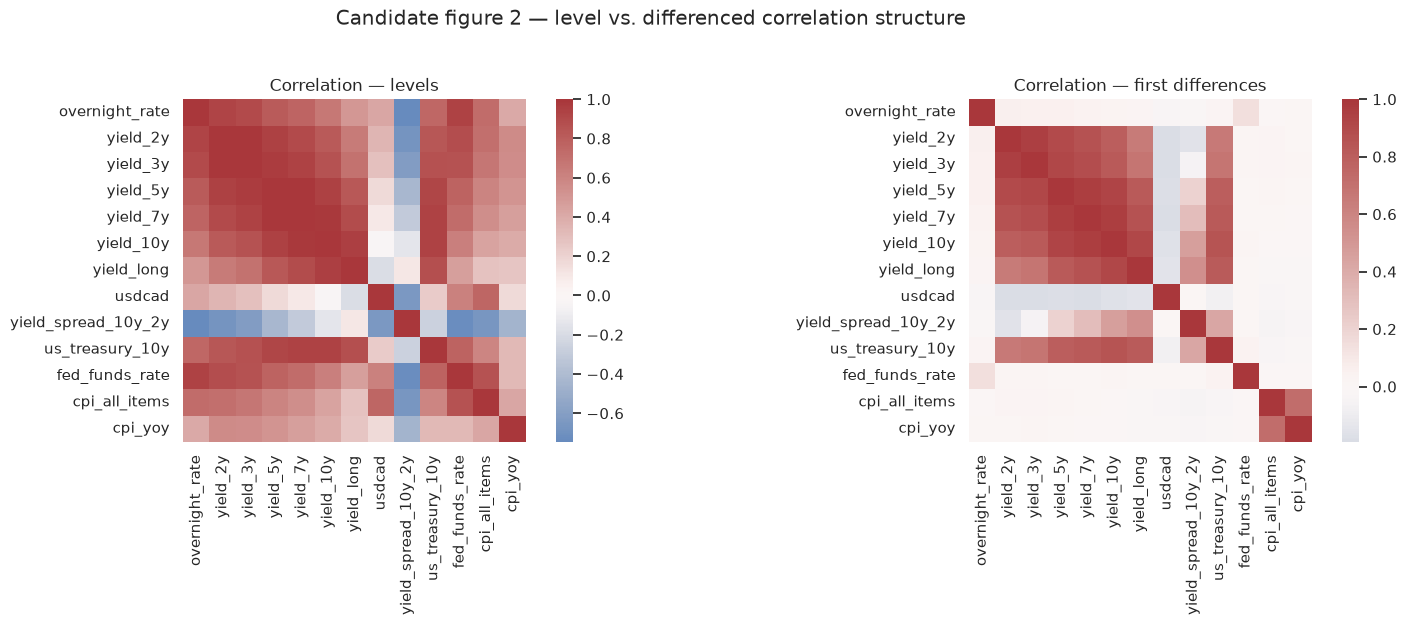

In [6]:
diff_cols = [c for c in daily.columns if c not in ("usdcad_legacy", "usdcad_current")]
levels = daily[diff_cols].dropna()
diffs = daily[diff_cols].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(levels.corr(), cmap="vlag", center=0, ax=axes[0], square=True)
axes[0].set_title("Correlation — levels")
sns.heatmap(diffs.corr(), cmap="vlag", center=0, ax=axes[1], square=True)
axes[1].set_title("Correlation — first differences")
fig.suptitle("Candidate figure 2 — level vs. differenced correlation structure", y=1.03)
fig.tight_layout()
plt.show()


**Interpretation:** in levels, almost everything is highly correlated (>0.8) with almost
everything else — including CPI against yields, which is not a claim anyone should walk into
Round 3 modeling believing at face value. In first differences the structure is much sparser and
more plausible: the BoC yield tenors move tightly together (as expected — one curve), and
`us_treasury_10y` co-moves with `yield_10y` (US/CA rate linkage), but CPI's daily change is
essentially uncorrelated with everything, consistent with it being a step function between
monthly releases.


## 6. ADF stationarity pre-checks

This is the section most directly useful outside this notebook: issues #22/#23 and PRs #33/#34
are actively deciding whether VECM belongs in the model suite, and VECM only makes sense if the
underlying series are integrated (I(1)) *and* cointegrated. This table doesn't settle
cointegration (that needs a Johansen test against a specific model spec, which is Round 3's job),
but it does establish the more basic precondition: are these series even I(1) in the first place.


In [7]:
def adf_row(series, label):
    series = series.dropna()
    stat, pval, *_ = adfuller(series, autolag="AIC")
    return {"series": label, "adf_stat": round(stat, 3), "p_value": round(pval, 4),
            "stationary_at_5pct": pval < 0.05}

rows = []
for col in diff_cols:
    rows.append(adf_row(daily[col], f"{col} (level)"))
    rows.append(adf_row(daily[col].diff(), f"{col} (first diff)"))

adf_table = pd.DataFrame(rows)
adf_table


,series,adf_stat,p_value,stationary_at_5pct
0,overnight_rate (level),-1.212,0.6682,False
1,overnight_rate (first diff),-8.189,0.0000,True
2,yield_2y (level),-1.175,0.6842,False
3,yield_2y (first diff),-37.667,0.0000,True
4,yield_3y (level),-1.257,0.6484,False
5,yield_3y (first diff),-37.910,0.0000,True
6,yield_5y (level),-1.559,0.5043,False
7,yield_5y (first diff),-37.660,0.0000,True
8,yield_7y (level),-1.690,0.4362,False
9,yield_7y (first diff),-63.846,0.0000,True


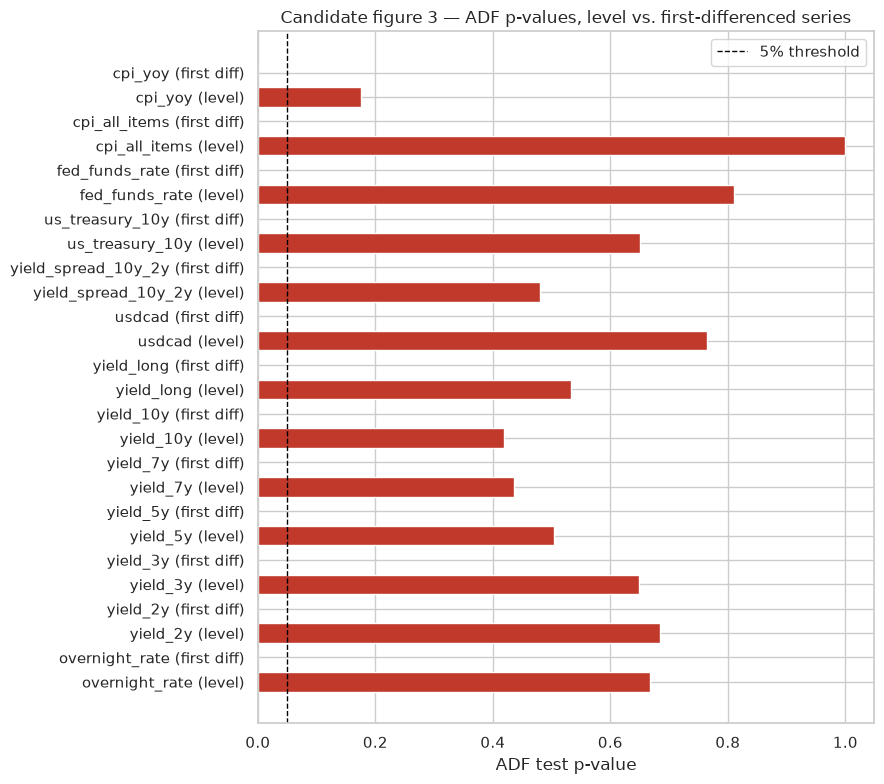

In [8]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = adf_table["stationary_at_5pct"].map({True: "#2e7d32", False: "#c0392b"})
ax.barh(adf_table["series"], adf_table["p_value"], color=colors)
ax.axvline(0.05, color="black", linestyle="--", linewidth=1, label="5% threshold")
ax.set_xlabel("ADF test p-value")
ax.set_title("Candidate figure 3 — ADF p-values, level vs. first-differenced series")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretation:** every level series fails to reject the unit-root null (p > 0.05) and every
first-differenced series rejects it cleanly (p ≈ 0) — the textbook I(1) pattern, and the reason
Round 3's VAR baselines need to run on differenced (or otherwise stationarity-corrected) data, not
raw levels.

One result worth being precise about rather than over-reading: `yield_spread_10y_2y` in levels
(p = 0.48) is **not** a standout — it sits inside the same 0.42–0.81 range as every other yield
level, not meaningfully lower. A spread being stationary while its components are each I(1) would
be a classic cointegration signature, but ADF on the spread alone doesn't establish that here; it
would need an actual Johansen test against a specific VAR/VECM spec, which is Round 3's job, not
something to claim off this table. Flagging it as a candidate to check in Round 3, not as a
finding.


## 7. Summary for the team

- **Built on:** Round 1 Path A only (Giti's PR #35) — Path B doesn't exist yet, so this isn't a
  judged comparison.
- **Missingness** is explainable: USD/CAD legacy/current split, CPI release-date alignment, and a
  small number of holiday-calendar mismatches. Nothing here blocks Round 3.
- **Don't correlate levels** — the differenced correlation heatmap (section 5) is the one to trust
  for any variable-selection decisions.
- **All rate/yield series are I(1)** (section 6); Round 3 VAR baselines should run on
  differences. ADF alone doesn't establish cointegration for any pair (including
  `yield_spread_10y_2y`, which is not a standout in this table) — that needs an actual Johansen
  test in Round 3, relevant to the open #22/#23 VECM discussion.
- **Round 2 team sync** (originally Fri Jul 31 per `M2_CHECKLIST.md`) has already passed as of
  this notebook — flagging so the team can confirm whether it happened and record the decision.
